# CDNMF — Contrastive Deep NMF for Community Detection

Paper: [Contrastive Deep Nonnegative Matrix Factorization for Community Detection](https://arxiv.org/abs/2311.02357) (ICASSP 2024)



## 1. Setup (fixed path — no nested folders)

In [1]:
#@title Clone / locate CDNMF (Colab or local)
import os, sys, subprocess
from pathlib import Path

def _clone(root):
    subprocess.check_call(['git', 'clone', 'https://github.com/6lyc/CDNMF.git', str(root)])

if Path('/content').exists():
    ROOT = Path('/content/CDNMF')
    os.chdir('/content')
    if not (ROOT / 'Model' / 'my_model.py').exists():
        if ROOT.exists():
            import shutil
            shutil.rmtree(ROOT)
        _clone(ROOT)
else:
    here = Path.cwd().resolve()
    candidates = [here / 'CDNMF', here, here.parent / 'CDNMF']
    ROOT = next((p for p in candidates if (p / 'Model' / 'my_model.py').exists()), None)
    if ROOT is None:
        ROOT = here / 'CDNMF'
        _clone(ROOT)

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('CWD:', os.getcwd())
print('Has model:', (ROOT / 'Model' / 'my_model.py').exists())
print('Has cora features:', (ROOT / 'Database' / 'cora' / 'features.txt').exists())
print('Has cora pretrain:', (ROOT / 'Log' / 'cora' / 'pretrain_params.pkl').exists())

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'numpy', 'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'networkx'])

import torch
print('torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CWD: /content/CDNMF
Has model: True
Has cora features: True
Has cora pretrain: True
torch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [2]:
#@title Patch Dataset loader (skip missing/empty walks.txt)
from pathlib import Path
import sys

# Do NOT create empty walks.txt - that produced KeyError: '' on citeseer/pubmed.
# Also skip allocating a dense NxN walks matrix when the file is missing (PubMed OOM).
Path('Dataset/dataset.py').write_text(r'''import os
import numpy as np
import linecache
import torch


def _nonempty_lines(path):
    if not path or not os.path.isfile(path) or os.path.getsize(path) == 0:
        return []
    lines = linecache.getlines(path)
    return [line.rstrip('\n') for line in lines]


def _parts(line):
    return line.strip().split()


class Dataset(object):

    def __init__(self, config):
        self.graph_file = config['graph_file']
        self.feature_file = config['feature_file']
        self.label_file = config['label_file']
        self.walks_file = config.get('walks_file') or None
        self.device = config['device']

        self.A, self.X, self.W, self.L, self.num_classes = self._load_data()

        self.num_nodes = self.A.shape[0]
        self.num_feas = self.X.shape[1]
        self.num_edges = np.sum(self.A) / 2

        self.A = torch.tensor(self.A, dtype=torch.float32, device=self.device)
        self.X = torch.tensor(self.X, dtype=torch.float32, device=self.device)
        if self.W.size > 0:
            self.W = torch.tensor(self.W, dtype=torch.float32, device=self.device)
        else:
            self.W = torch.empty(0, device=self.device)
        self.L = torch.tensor(self.L, dtype=torch.float32, device=self.device)
        print('nodes {}, edes {}, features {}, classes {}'.format(self.num_nodes, self.num_edges, self.num_feas, self.num_classes))


    def _load_data(self):
        lines = _nonempty_lines(self.label_file)

        #===========load label============
        node_map = {}
        label_map = {}
        Y = []
        cnt = 0
        for line in lines:
            parts = _parts(line)
            if not parts:
                continue
            node_map[parts[0]] = len(node_map)
            y = []
            for label in parts[1:]:
                if not label:
                    continue
                if label not in label_map:
                    label_map[label] = cnt
                    cnt += 1
                y.append(label_map[label])
            Y.append(y if y else [0])
        num_classes = len(label_map)
        num_nodes = len(node_map)

        L = np.array([la[0] for la in Y])

        #=========load feature==========
        lines = _nonempty_lines(self.feature_file)
        feat_parts = next((_parts(line) for line in lines if _parts(line)), None)
        num_features = (len(feat_parts) - 1) if feat_parts else 0
        X = np.zeros((num_nodes, num_features), dtype=np.float32)

        for line in lines:
            parts = _parts(line)
            if len(parts) < 2 or parts[0] not in node_map:
                continue
            node_id = node_map[parts[0]]
            X[node_id] = np.array([float(x) for x in parts[1:num_features + 1]])

        #==========load graph========
        A = np.zeros((num_nodes, num_nodes), dtype=np.float32)
        lines = _nonempty_lines(self.graph_file)
        for line in lines:
            parts = _parts(line)
            if len(parts) < 2 or parts[0] not in node_map or parts[1] not in node_map:
                continue
            idx1 = node_map[parts[0]]
            idx2 = node_map[parts[1]]
            A[idx2, idx1] = 1.0
            A[idx1, idx2] = 1.0

        #=========load walks========
        walk_lines = _nonempty_lines(self.walks_file)
        if walk_lines:
            W = np.zeros((num_nodes, num_nodes), dtype=np.float32)
            for line in walk_lines:
                parts = _parts(line)
                if len(parts) < 2 or parts[0] not in node_map or parts[1] not in node_map:
                    continue
                idx1 = node_map[parts[0]]
                idx2 = node_map[parts[1]]
                W[idx2, idx1] = 1.0
                W[idx1, idx2] = 1.0
        else:
            W = np.zeros((0, 0), dtype=np.float32)

        return A, X, W, L, num_classes
''', encoding='utf-8')

for name in list(sys.modules):
    if name == 'Dataset' or name.startswith('Dataset.'):
        del sys.modules[name]
print('Patched Dataset loader: missing/empty walks.txt is skipped')


Patched Dataset loader: missing/empty walks.txt is skipped


In [3]:
#@title Patch model to avoid CUDA OOM on PubMed
from pathlib import Path
import sys

# Original contra_loss / reconstruction / Laplacian all build NxN tensors.
# PubMed N=19717 => each matrix is ~1.45 GiB and the T4 runs out of memory.
Path('Model/my_model.py').write_text(r'''# CDNMF

import os
import pickle
import torch
import torch.nn.functional as F


class Model(torch.nn.Module):
    def __init__(self, config):
        super(Model, self).__init__()
        self.config = config
        self.device = config['device']
        self.net_shape = config['net_shape']
        self.att_shape = config['att_shape']
        self.net_input_dim = config['net_input_dim']
        self.att_input_dim = config['att_input_dim']
        self.is_init = config['is_init']
        self.pretrain_params_path = config['pretrain_params_path']
        self.tau = config['tau']
        self.conc = config['conc']
        self.negc = config['negc']
        self.rec = config['rec']
        self.r = config['r']
        self.model_path = config['model_path']

        self.fc1 = torch.nn.Linear(self.net_shape[-1], self.net_shape[1])
        self.fc2 = torch.nn.Linear(self.net_shape[1], self.net_shape[0])

        self.fc3 = torch.nn.Linear(self.att_shape[-1], self.net_shape[1])
        self.fc4 = torch.nn.Linear(self.net_shape[1], self.net_shape[0])

        self.U = torch.nn.ParameterDict({})
        self.V = torch.nn.ParameterDict({})

        if os.path.isfile(self.pretrain_params_path):
            with open(self.pretrain_params_path, 'rb') as handle:
                self.U_init, self.V_init = pickle.load(handle)

        if self.is_init:
            module = 'net'
            for i in range(len(self.net_shape)):
                name = module + str(i)
                self.U[name] = torch.nn.Parameter(torch.tensor(self.U_init[name], dtype=torch.float32))
            self.V[name] = torch.nn.Parameter(torch.tensor(self.V_init[name], dtype=torch.float32))

            module = 'att'
            for i in range(len(self.att_shape)):
                name = module + str(i)
                self.U[name] = torch.nn.Parameter(torch.tensor(self.U_init[name], dtype=torch.float32))
            self.V[name] = torch.nn.Parameter(torch.tensor(self.V_init[name], dtype=torch.float32))
        else:
            module = 'net'
            for i in range(len(self.net_shape)):
                name = module + str(i)
                self.U[name] = torch.nn.Parameter(torch.rand_like(torch.tensor(self.U_init[name], dtype=torch.float32)))
            self.V[name] = torch.nn.Parameter(torch.rand_like(torch.tensor(self.V_init[name], dtype=torch.float32)))

            module = 'att'
            for i in range(len(self.att_shape)):
                name = module + str(i)
                self.U[name] = torch.nn.Parameter(torch.rand_like(torch.tensor(self.U_init[name]), dtype=torch.float32))
            self.V[name] = torch.nn.Parameter(torch.rand_like(torch.tensor(self.V_init[name], dtype=torch.float32)))

    def projection1(self, z: torch.Tensor) -> torch.Tensor:
        z = F.elu(self.fc1(z.t()))
        return self.fc2(z)

    def projection2(self, z: torch.Tensor) -> torch.Tensor:
        z = F.elu(self.fc3(z.t()))
        return self.fc4(z)

    def sim(self, z1: torch.Tensor, z2: torch.Tensor):
        z1 = F.normalize(z1)
        z2 = F.normalize(z2)
        return torch.mm(z1, z2.t())

    def semi_loss(self, z1: torch.Tensor, z2: torch.Tensor, chunk_size: int = 4096):
        # Same as the paper loss, but never materializes an N x N similarity matrix.
        z1 = F.normalize(z1)
        z2 = F.normalize(z2)
        n = z1.size(0)
        tau = self.tau

        self.index_net = torch.argmax(self.V1, dim=0).long()
        between_diag = torch.exp((z1 * z2).sum(dim=1) / tau)

        refl_sum = z1.new_zeros(n)
        refl_pos_sum = z1.new_zeros(n)
        for start in range(0, n, chunk_size):
            end = min(start + chunk_size, n)
            refl = torch.exp(torch.mm(z1, z1[start:end].t()) / tau)
            refl_sum = refl_sum + refl.sum(dim=1)
            same = self.index_net.unsqueeze(1).eq(self.index_net[start:end].unsqueeze(0))
            refl_pos_sum = refl_pos_sum + (refl * same).sum(dim=1)
        return -torch.log(between_diag / (refl_sum - refl_pos_sum + between_diag))

    def contra_loss(self, z1: torch.Tensor, z2: torch.Tensor,
             mean: bool = True):
        h1 = self.projection1(z1)
        h2 = self.projection2(z2)

        ret = self.semi_loss(h1, h2)
        ret = ret.mean() if mean else ret.sum()

        return ret

    def forward(self):
        self.V1 = self.V['net' + str(len(self.net_shape) - 1)]
        self.V2 = self.V['att' + str(len(self.att_shape) - 1)]
        return self.V1

    def _factor_pair(self, prefix, n_layers):
        C = self.U[prefix + '0']
        for i in range(1, n_layers):
            C = torch.mm(C, self.U[prefix + str(i)])
        V = self.V[prefix + str(n_layers - 1)]
        return C, V

    def _recon_fro(self, target, C, V):
        # ||target - C@V||_F^2 without forming C@V when that would be N x N
        inner = torch.trace(torch.mm(C.t(), torch.mm(target, V.t())))
        pnorm = torch.trace(torch.mm(torch.mm(C.t(), C), torch.mm(V, V.t())))
        tnorm = torch.square(torch.norm(target))
        return tnorm + pnorm - 2 * inner

    def _trace_lap(self, Z, A):
        # trace(Z (D-A) Z.T) without forming the Laplacian
        deg = torch.sum(A, dim=1)
        return (Z.pow(2).sum(0) * deg).sum() - torch.sum(torch.mm(Z, A) * Z)

    def loss(self, graph):

        A = graph.A
        X = graph.X.T

        C1, V1 = self._factor_pair('net', len(self.net_shape))
        loss1 = self._recon_fro(A, C1, V1)

        C2, V2 = self._factor_pair('att', len(self.att_shape))
        loss2 = self._recon_fro(X, C2, V2)

        loss3 = self.contra_loss(self.V1, self.V2)

        i = len(self.net_shape) - 1
        loss4 = self._trace_lap(self.V['net' + str(i)], A)
        i = len(self.att_shape) - 1
        loss4 = loss4 + self._trace_lap(self.V['att' + str(i)], A)

        loss5 = 0
        for i in range(len(self.net_shape)):
            zero1 = torch.zeros_like(self.U['net' + str(i)])
            X1 = torch.where(self.U['net' + str(i)] > 0, zero1, self.U['net' + str(i)])
            loss5 = loss5 + torch.square(torch.norm(X1))
        zero1 = torch.zeros_like(self.V['net' + str(i)])
        X1 = torch.where(self.V['net' + str(i)] > 0, zero1, self.V['net' + str(i)])
        loss5 = loss5 + torch.square(torch.norm(X1))

        for i in range(len(self.att_shape)):
            zero2 = torch.zeros_like(self.U['att' + str(i)])
            X2 = torch.where(self.U['att' + str(i)] > 0, zero2, self.U['att' + str(i)])
            loss5 = loss5 + torch.square(torch.norm(X2))
        i = len(self.att_shape) - 1
        zero2 = torch.zeros_like(self.V['att' + str(i)])
        X2 = torch.where(self.V['att' + str(i)] > 0, zero2, self.V['att' + str(i)])
        loss5 = loss5 + torch.square(torch.norm(X2))

        loss = self.rec*(loss1 + loss2) + self.conc*loss3 + self.r*loss4 + self.negc*loss5

        return loss, loss1, loss2, loss3, loss4, loss5
''', encoding='utf-8')

for name in list(sys.modules):
    if name == 'Model' or name.startswith('Model.'):
        del sys.modules[name]
print('Patched Model/my_model.py (chunked contrastive loss, no NxN intermediates)')


Patched Model/my_model.py (chunked contrastive loss, no NxN intermediates)


In [4]:
print('Walks blank-line handling is already in Dataset/dataset.py. Nothing to patch.')


Walks blank-line handling is already in Dataset/dataset.py. Nothing to patch.


## 2. Choose run mode

| Mode | What it does | Use for |
|------|----------------|---------|
| `smoke` | 1 run × 30 epochs | only check GPU works |
| `project` | **1 run × 550 epochs** | **your Project 1 slides** |
| `paper` | 20 runs × 550 epochs | full Table 1 average (slow) |

In [5]:
#@title Config
DATASET = 'pubmed'  #@param ['cora', 'citeseer', 'pubmed']
RUN_MODE = 'paper'  #@param ['smoke', 'project', 'paper']
FORCE_PRETRAIN = False  #@param {type: 'boolean'}

PAPER_CFG = {
    'cora': {
        'net_shape': [1000, 500, 7],
        'att_shape': [500, 200, 7],
        'tau': 1.3, 'conc': 5, 'negc': 400, 'rec': 1, 'r': 3,
        'learning_rate': 0.01, 'epoch': 550, 'run': 20,
    },
    'citeseer': {
        'net_shape': [256, 64, 6],
        'att_shape': [500, 100, 6],
        'tau': 1.5, 'conc': 5, 'negc': 3000, 'rec': 1, 'r': 1,
        'learning_rate': 0.001, 'epoch': 1000, 'run': 20,
    },
    'pubmed': {
        'net_shape': [512, 64, 3],
        'att_shape': [200, 100, 3],
        'tau': 0.5, 'conc': 1, 'negc': 100, 'rec': 1, 'r': 1,
        'learning_rate': 0.01, 'epoch': 600, 'run': 20,
    },
}

cfg = dict(PAPER_CFG[DATASET])
if RUN_MODE == 'smoke':
    cfg['epoch'], cfg['run'] = 30, 1
elif RUN_MODE == 'project':
    cfg['epoch'], cfg['run'] = cfg['epoch'], 1   # full epochs, 1 run (good for slides)
elif RUN_MODE == 'paper':
    pass  # keep 20 runs

print(f'Mode={RUN_MODE} | Dataset={DATASET} | runs={cfg["run"]} | epochs={cfg["epoch"]}')
print('Paper Cora target: ACC≈0.6081, NMI≈0.4006')

Mode=paper | Dataset=pubmed | runs=20 | epochs=600
Paper Cora target: ACC≈0.6081, NMI≈0.4006


## 3. Load data

In [6]:
import os, sys, random, numpy as np, torch
from pathlib import Path
from time import perf_counter as t
import matplotlib.pyplot as plt

# Always use the patched Dataset.py from the previous cell
for name in list(sys.modules):
    if name == 'Dataset' or name.startswith('Dataset.'):
        del sys.modules[name]

from Dataset.dataset import Dataset
from Model.my_model import Model
from PreTrainer.pretrainer import PreTrainer
from Utils.evaluate import clusterscores

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

os.makedirs(f'Log/{DATASET}', exist_ok=True)

walks_path = Path(f'./Database/{DATASET}/walks.txt')
walks_file = str(walks_path) if walks_path.is_file() and walks_path.stat().st_size > 0 else None
print('walks_file:', walks_file)

graph = Dataset({
    'feature_file': f'./Database/{DATASET}/features.txt',
    'graph_file': f'./Database/{DATASET}/edges.txt',
    'walks_file': walks_file,
    'label_file': f'./Database/{DATASET}/group.txt',
    'device': device,
})
print('num classes r =', graph.num_classes)

device: cuda:0
walks_file: None
nodes 19717, edes 44325.5, features 500, classes 3
num classes r = 3


## 4. Pre-training

If init ACC (next section) is very low (&lt;0.40 on Cora), re-run this cell with `FORCE_PRETRAIN=True` in the config cell.

In [7]:
pretrain_path = f'./Log/{DATASET}/pretrain_params.pkl'

pretrain_config = {
    'net_shape': cfg['net_shape'],
    'att_shape': cfg['att_shape'],
    'net_input_dim': graph.num_nodes,
    'att_input_dim': graph.num_feas,
    'seed': 42,
    'pre_iterations': 100,
    'pretrain_params_path': pretrain_path,
}

need = FORCE_PRETRAIN or (not os.path.isfile(pretrain_path)) or os.path.getsize(pretrain_path) < 10000
if need:
    print('Running layer-wise NMF pre-training (can take several minutes)...')
    pretrainer = PreTrainer(pretrain_config)
    pretrainer.pre_training(graph.A.detach().cpu().numpy(), 'net')
    pretrainer.pre_training(graph.X.t().detach().cpu().numpy(), 'att')
    print('Saved', pretrain_path, 'size=', os.path.getsize(pretrain_path))
else:
    print('Using existing pretrain:', pretrain_path, 'size=', os.path.getsize(pretrain_path))

Using existing pretrain: ./Log/pubmed/pretrain_params.pkl size= 110555626


## 5. Fine-tuning + curves (for Slide 4)

In [8]:
import gc, sys

def eval_now(model, graph):
    with torch.no_grad():
        V = model()
        pred = np.argmax(V.detach().cpu().numpy(), axis=0)
        true = graph.L.detach().cpu().numpy()
        return clusterscores(pred, true)


for name in list(sys.modules):
    if name == 'Model' or name.startswith('Model.'):
        del sys.modules[name]
from Model.my_model import Model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_config = {
    'device': device,
    'net_shape': cfg['net_shape'],
    'att_shape': cfg['att_shape'],
    'net_input_dim': graph.num_nodes,
    'att_input_dim': graph.num_feas,
    'is_init': True,
    'pretrain_params_path': pretrain_path,
    'tau': cfg['tau'],
    'conc': cfg['conc'],
    'negc': cfg['negc'],
    'rec': cfg['rec'],
    'r': cfg['r'],
    'model_path': f'./Log/{DATASET}/{DATASET}_model.pkl',
}

# ---- sanity check: ACC right after loading pretrain (before fine-tune) ----
probe = Model(model_config).to(device)
init_scores = eval_now(probe, graph)
print(f'Init (pretrained only) ACC={init_scores["ACC"]:.4f} NMI={init_scores["NMI"]:.4f}')
if DATASET == 'cora' and init_scores['ACC'] < 0.40:
    print('WARNING: init ACC is low. Set FORCE_PRETRAIN=True, re-run config + pretrain + this cell.')
del probe
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

acc_runs, nmi_runs = [], []
history = {'epoch': [], 'loss': [], 'ACC': [], 'NMI': []}
start = t()

# Slides need 1 full run, not 20. Re-run THIS cell after interrupting the 20-run job.
n_runs = 1
n_epochs = cfg['epoch']
print(f'Fast slides run: {n_runs} run x {n_epochs} epochs (paper mode would be {cfg["run"]} runs)')

for run in range(n_runs):
    model = Model(model_config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()
        V = model()
        loss, *_ = model.loss(graph)
        loss.backward()
        optimizer.step()

        log_this = epoch == 1 or epoch % 100 == 0 or epoch == n_epochs
        if log_this:
            scores = eval_now(model, graph)
            history['epoch'].append(epoch)
            history['loss'].append(loss.item())
            history['ACC'].append(scores['ACC'])
            history['NMI'].append(scores['NMI'])
            print(
                f"[run {run+1}/{n_runs}] epoch {epoch:4d} | "
                f"loss={loss.item():.2f} | ACC={scores['ACC']:.4f} | NMI={scores['NMI']:.4f}"
            )

    acc_runs.append(scores['ACC'])
    nmi_runs.append(scores['NMI'])
    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('=' * 60)
print(f'Dataset: {DATASET} | mode: {RUN_MODE}')
print(f'ACC: {np.mean(acc_runs):.4f} ± {np.std(acc_runs):.4f}')
print(f'NMI: {np.mean(nmi_runs):.4f} ± {np.std(nmi_runs):.4f}')
print(f'Time: {t()-start:.1f}s')
print('Paper Table 1 Cora: ACC=0.6081 | NMI=0.4006')
print('=' * 60)


Init (pretrained only) ACC=0.5969 NMI=0.1921
Fast slides run: 1 run x 600 epochs (paper mode would be 20 runs)
[run 1/1] epoch    1 | loss=172538.05 | ACC=0.5927 | NMI=0.1869
[run 1/1] epoch  100 | loss=153471.48 | ACC=0.5116 | NMI=0.1516
[run 1/1] epoch  200 | loss=142472.97 | ACC=0.5104 | NMI=0.1732
[run 1/1] epoch  300 | loss=134695.67 | ACC=0.5357 | NMI=0.1772
[run 1/1] epoch  400 | loss=127486.06 | ACC=0.5802 | NMI=0.1844
[run 1/1] epoch  500 | loss=122661.70 | ACC=0.6126 | NMI=0.1978
[run 1/1] epoch  600 | loss=117338.97 | ACC=0.6600 | NMI=0.2232
Dataset: pubmed | mode: paper
ACC: 0.6600 ± 0.0000
NMI: 0.2232 ± 0.0000
Time: 293.0s
Paper Table 1 Cora: ACC=0.6081 | NMI=0.4006


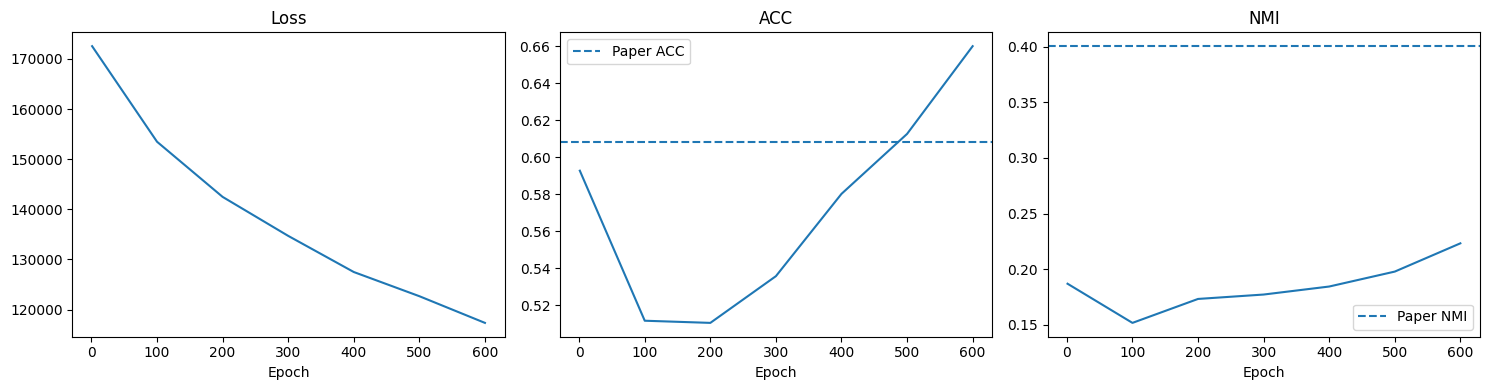

Saved figure: Log/pubmed/curves_paper.png


,Setting,ACC,NMI
0,Original paper (Table 1),0.665300,0.233000
1,Our reproduction (paper),0.659989,0.223224


Download Log/pubmed/curves_*.png and comparison_*.csv for your slides


In [9]:
#@title Plot curves for Slide 4
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['epoch'], history['loss'])
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(history['epoch'], history['ACC'])
axes[1].axhline(0.6081, ls='--', label='Paper ACC')
axes[1].set_title('ACC'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['epoch'], history['NMI'])
axes[2].axhline(0.4006, ls='--', label='Paper NMI')
axes[2].set_title('NMI'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
fig_path = f'Log/{DATASET}/curves_{RUN_MODE}.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved figure:', fig_path)

# Comparison table for slides
import pandas as pd
paper = {'cora': (0.6081, 0.4006), 'citeseer': (0.4756, 0.2559), 'pubmed': (0.6653, 0.2330)}
p_acc, p_nmi = paper[DATASET]
df = pd.DataFrame([
    {'Setting': 'Original paper (Table 1)', 'ACC': p_acc, 'NMI': p_nmi},
    {'Setting': f'Our reproduction ({RUN_MODE})', 'ACC': float(np.mean(acc_runs)), 'NMI': float(np.mean(nmi_runs))},
])
display(df)
df.to_csv(f'Log/{DATASET}/comparison_{RUN_MODE}.csv', index=False)
print('Download Log/{}/curves_*.png and comparison_*.csv for your slides'.format(DATASET))